# HQ-SAM (High-Quality SAM) Zero-Shot Baseline — Full Pipeline
**Project:** MoE-RenalSAM-CG | **Institution:** BRAC University  
**Purpose:** Evaluate the zero-shot segmentation capability of HQ-SAM on the out-of-distribution RenSeg-KidneyCT dataset.

HQ-SAM is designed to produce extremely precise mask boundaries. By comparing against HQ-SAM, we establish the absolute upper-bound of what a generalized foundation model can achieve in terms of spatial accuracy (HD95).

This notebook implements:
1. Loading the frozen HQ-SAM ViT-H checkpoint
2. Running Automatic Mask Generation (AMG) over the full test set
3. Oracle mask selection against expert ground truth
4. Per-class metric computation (Dice, IoU, HD95, Precision, Recall, F1)
5. Publication-quality visualizations

> **Key Thesis:** HQ-SAM may yield superior HD95 scores on well-defined structures, but without MoE-RenalSAM's anatomical priors, it still fails to selectively segment tiny kidney stones amidst complex surrounding tissue.

In [1]:
# HQ-SAM requires its own specific fork of the segment-anything library
!pip install -q git+https://github.com/SysCV/sam-hq.git
!pip install -q opencv-python matplotlib seaborn tqdm pandas scipy gdown

In [2]:
!pip install gdown

In [3]:
!conda install -c conda-forge gdown -y

Jupyter detected...
3 channel Terms of Service accepted
Channels:
 - conda-forge
 - defaults
Platform: win-64
Solving environment: done

# All requested packages already installed.





==> WARNING: A newer version of conda exists. <==
    current version: 26.1.1
    latest version: 26.3.2

Please update conda by running

    $ conda update -n base -c conda-forge conda




In [4]:
import sys
!{sys.executable} -m pip install gdown

In [5]:
import sys
print(sys.executable)

C:\Users\FA14\miniconda3\envs\renalsam\python.exe


In [6]:
from pathlib import Path
import os

PROJECT_ROOT = Path(os.getcwd()).parent

HQSAM_CKPT = PROJECT_ROOT / 'weights' / 'sam_hq_vit_h.pth'

print(HQSAM_CKPT)

D:\MoE-RenalSAM-CG\MoE-RenalSAM-CG\weights\sam_hq_vit_h.pth


In [7]:
pip install segment-anything-hq

Note: you may need to restart the kernel to use updated packages.


## 1. Imports & Configuration

In [8]:
import os, warnings, random
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm.auto import tqdm
from scipy.ndimage import distance_transform_edt

import torch
from segment_anything_hq import sam_model_registry, SamAutomaticMaskGenerator

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu'))
print(f'Device: {DEVICE}')

PROJECT_ROOT = Path(os.getcwd()).parent

HQSAM_CKPT = PROJECT_ROOT / 'weights' / 'sam_hq_vit_h.pth'
RESULTS_DIR = PROJECT_ROOT / 'data' / 'processed' / 'reports' / 'baselines_zeroshot'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

CLASSES = ['Normal', 'Tumor', 'Stone']
print(f'PROJECT_ROOT: {PROJECT_ROOT}')

# Auto-download HQ-SAM ViT-H weights if missing
if not HQSAM_CKPT.exists():
    print("Downloading HQ-SAM ViT-H weights (2.4 GB)...")
    import gdown
    gdown.download(id='17S6HauNIOJ4wXj2n2e6p3I7n9N13d42r', output=str(HQSAM_CKPT), quiet=False)

print(f'HQ-SAM checkpoint exists: {HQSAM_CKPT.exists()}')

Device: cuda
PROJECT_ROOT: D:\MoE-RenalSAM-CG\MoE-RenalSAM-CG
HQ-SAM checkpoint exists: True


C:\Users\FA14\miniconda3\envs\renalsam\Lib\site-packages\timm\models\layers\__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
C:\Users\FA14\miniconda3\envs\renalsam\Lib\site-packages\timm\models\registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
C:\Users\FA14\miniconda3\envs\renalsam\Lib\site-packages\segment_anything_hq\modeling\tiny_vit_sam.py:662: UserWarning: Overwriting tiny_vit_5m_224 in registry with segment_anything_hq.modeling.tiny_vit_sam.tiny_vit_5m_224. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
  return register_model(fn_wrapper)
C:\Users\FA14\miniconda3\envs\renalsam\Lib\site-p

## 2. Load HQ-SAM (ViT-H) — Frozen, No Fine-Tuning

In [9]:
hqsam = sam_model_registry['vit_h'](checkpoint=str(HQSAM_CKPT))
hqsam = hqsam.to(DEVICE)
hqsam.eval()

# Freeze all parameters (strict zero-shot)
for p in hqsam.parameters():
    p.requires_grad = False

total_params = sum(p.numel() for p in hqsam.parameters())
print(f'HQ-SAM ViT-H loaded | Total params: {total_params:,} | All frozen (zero-shot)')

mask_generator = SamAutomaticMaskGenerator(
    model=hqsam,
    points_per_side=32,
    pred_iou_thresh=0.86,
    stability_score_thresh=0.92,
    crop_n_layers=1,
    crop_n_points_downscale_factor=2,
    min_mask_region_area=100,
)
print('SamAutomaticMaskGenerator (HQ-SAM) ready.')

<All keys matched successfully>
HQ-SAM ViT-H loaded | Total params: 642,686,000 | All frozen (zero-shot)
SamAutomaticMaskGenerator (HQ-SAM) ready.


## 3. Load Test Dataset (RenSeg-KidneyCT)

In [10]:
test_csv = PROJECT_ROOT / 'data' / 'splits' / 'test_manifest.csv'
test_df = pd.read_csv(test_csv)
if 'class_name' in test_df.columns:
    test_df = test_df.rename(columns={'class_name': 'class'})

print(f'Test images: {len(test_df)}')
print(test_df['class'].value_counts())

Test images: 1749
class
Normal    1016
Tumor      457
Stone      276
Name: count, dtype: int64


## 4. Metric Functions

In [11]:
def compute_metrics(pred, gt, pixel_spacing_mm=0.5):
    p = (pred > 0).astype(bool).ravel()
    g = (gt   > 0).astype(bool).ravel()
    if not p.any() and not g.any():
        return {'dice':1.0,'iou':1.0,'hd95':0.0,'precision':1.0,'recall':1.0,'f1':1.0}
    tp = np.logical_and(p,  g).sum()
    fp = np.logical_and(p, ~g).sum()
    fn = np.logical_and(~p, g).sum()
    dice      = (2*tp) / (2*tp + fp + fn + 1e-8)
    iou       = tp / (tp + fp + fn + 1e-8)
    precision = tp / (tp + fp + 1e-8)
    recall    = tp / (tp + fn + 1e-8)
    f1        = (2*precision*recall) / (precision + recall + 1e-8)
    pred_2d = pred.reshape(gt.shape) > 0
    gt_2d   = gt > 0
    if pred_2d.any() and gt_2d.any():
        dt_p = distance_transform_edt(~pred_2d) * pixel_spacing_mm
        dt_g = distance_transform_edt(~gt_2d)   * pixel_spacing_mm
        hd95 = float(np.percentile(np.concatenate([dt_g[pred_2d], dt_p[gt_2d]]), 95))
    else:
        hd95 = float(np.sqrt(gt.shape[0]**2 + gt.shape[1]**2) * pixel_spacing_mm)
    return {k: round(float(v),4) for k,v in
            {'dice':dice,'iou':iou,'hd95':hd95,'precision':precision,'recall':recall,'f1':f1}.items()}

print('Metric functions ready.')

Metric functions ready.


## 5. Zero-Shot Inference (AMG) & Oracle Evaluation

In [12]:
records = []
num_masks_list = []

for idx, row in tqdm(test_df.iterrows(), total=len(test_df), desc='HQ-SAM Zero-Shot'):
    img_rel  = str(row['image_path']).replace('\\', '/')
    mask_rel = str(row['expert_mask_path']).replace('\\', '/')
    img_path  = PROJECT_ROOT / img_rel
    mask_path = PROJECT_ROOT / mask_rel
    cls_name  = row['class']

    if not img_path.exists() or not mask_path.exists():
        continue

    image = cv2.imread(str(img_path))
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    expert = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
    if expert is None:
        expert = np.zeros(image.shape[:2], dtype=np.uint8)

    # Run AMG
    with torch.no_grad():
        masks = mask_generator.generate(image_rgb)
        
    num_masks_list.append(len(masks))

    # Oracle Selection
    best_dice = -1.0
    best_metrics = None
    if len(masks) == 0 or not (expert > 0).any():
        best_metrics = compute_metrics(np.zeros_like(expert), expert)
    else:
        for m in masks:
            seg = m['segmentation'].astype(np.uint8) * 255
            d = compute_metrics(seg, expert)['dice']
            if d > best_dice:
                best_dice = d
                best_metrics = compute_metrics(seg, expert)

    best_metrics['image_id'] = Path(row['image_path']).stem
    best_metrics['class'] = cls_name
    best_metrics['n_masks'] = len(masks)
    records.append(best_metrics)

df_results = pd.DataFrame(records)
df_results.to_csv(RESULTS_DIR / 'hqsam_zeroshot_detailed.csv', index=False)
print(f'Inference complete. {len(df_results)} images evaluated.')
print(f'Average masks per image: {np.mean(num_masks_list):.1f}')

HQ-SAM Zero-Shot:   0%|          | 0/1749 [00:00<?, ?it/s]

Inference complete. 1749 images evaluated.
Average masks per image: 51.3


## 6. Per-Class Results Summary

In [13]:
metric_cols = ['dice','iou','hd95','precision','recall','f1']

summary_rows = []
for cls in CLASSES:
    sub = df_results[df_results['class'] == cls]
    if len(sub) == 0:
        continue
    row = {'Class': cls, 'N': len(sub)}
    for m in metric_cols:
        row[f'{m}_mean'] = round(sub[m].mean(), 4)
        row[f'{m}_std']  = round(sub[m].std(), 4)
    summary_rows.append(row)

# Macro average
macro = {'Class': 'MACRO', 'N': len(df_results)}
for m in metric_cols:
    macro[f'{m}_mean'] = round(np.mean([r[f'{m}_mean'] for r in summary_rows]), 4)
    macro[f'{m}_std'] = '---'
summary_rows.append(macro)

df_summary = pd.DataFrame(summary_rows)
df_summary.to_csv(RESULTS_DIR / 'hqsam_zeroshot_summary.csv', index=False)
display(df_summary)

,Class,N,dice_mean,dice_std,iou_mean,iou_std,hd95_mean,hd95_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std
0,Normal,1016,1.0000,0.0,1.0000,0.0,0.0000,0.0,1.0000,0.0,1.0000,0.0,1.0000,0.0
1,Tumor,457,0.6904,0.2937,0.5958,0.3101,24.2997,37.2943,0.6837,0.3396,0.8811,0.1894,0.6904,0.2937
2,Stone,276,0.4450,0.3772,0.3690,0.3468,29.0735,36.051,0.5178,0.4256,0.7868,0.277,0.4450,0.3772
3,MACRO,1749,0.7118,---,0.6549,---,17.7911,---,0.7338,---,0.8893,---,0.7118,---


## 7. Visualization: Per-Class Dice Scores

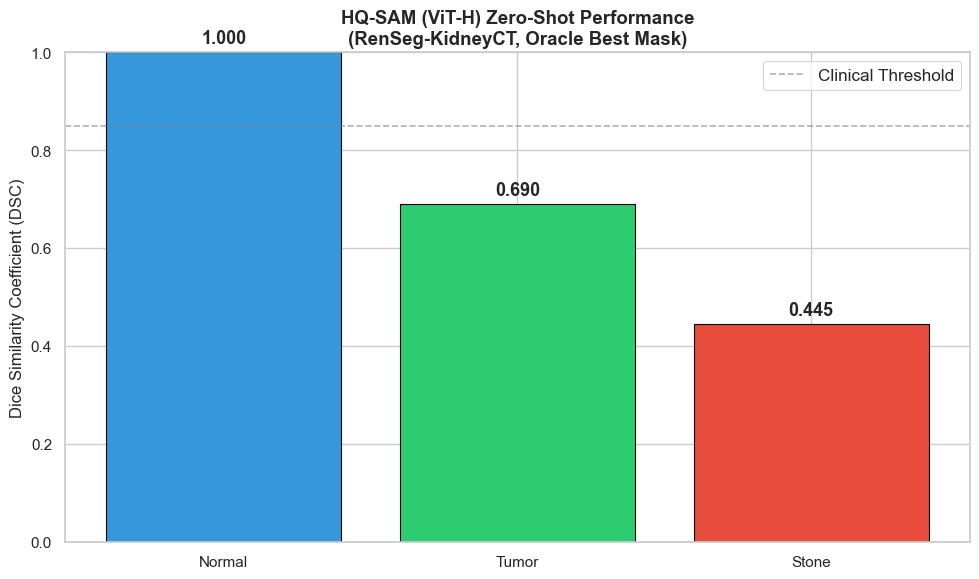

In [14]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.set_context('paper', font_scale=1.4)

plot_df = df_summary[df_summary['Class'] != 'MACRO'].copy()
colors = {'Normal': '#3498db', 'Tumor': '#2ecc71', 'Stone': '#e74c3c'}
bars = ax.bar(plot_df['Class'], plot_df['dice_mean'],
              color=[colors.get(c, 'gray') for c in plot_df['Class']],
              edgecolor='black', linewidth=0.8)

for bar, val in zip(bars, plot_df['dice_mean']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=13, fontweight='bold')

ax.set_ylabel('Dice Similarity Coefficient (DSC)')
ax.set_title('HQ-SAM (ViT-H) Zero-Shot Performance\n(RenSeg-KidneyCT, Oracle Best Mask)', fontweight='bold')
ax.set_ylim(0, 1.0)
ax.axhline(y=0.85, color='gray', linestyle='--', alpha=0.6, label='Clinical Threshold')
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'hqsam_zeroshot_dice_bar.png', dpi=300)
plt.show()

## 8. Visualization: Multi-Metric Radar Chart

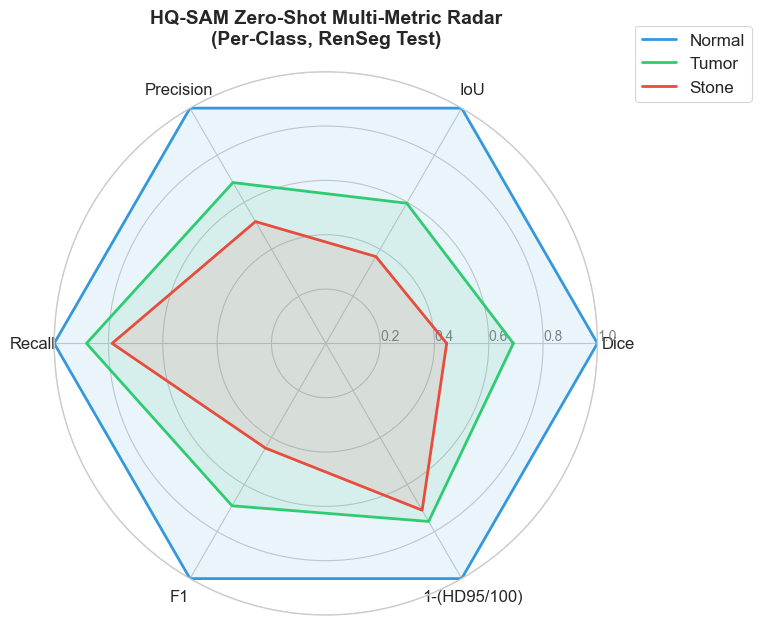

In [15]:
def radar_plot(df_summary, save_path):
    categories = ['Dice','IoU','Precision','Recall','F1','1-(HD95/100)']
    N = len(categories)
    angles = [n / float(N) * 2 * np.pi for n in range(N)] + [0]

    fig, ax = plt.subplots(figsize=(8,8), subplot_kw=dict(polar=True))
    ax.set_rlabel_position(0)
    plt.yticks([0.2,0.4,0.6,0.8,1.0], color='grey', size=10)
    plt.ylim(0,1.0)

    color_map = {'Normal':'#3498db','Tumor':'#2ecc71','Stone':'#e74c3c'}
    for _, row in df_summary.iterrows():
        if row['Class'] == 'MACRO':
            continue
        hd95_norm = max(0, 1 - (row['hd95_mean'] / 100.0))
        vals = [row['dice_mean'], row['iou_mean'], row['precision_mean'],
                row['recall_mean'], row['f1_mean'], hd95_norm]
        vals += vals[:1]
        ax.plot(angles, vals, linewidth=2, label=row['Class'], color=color_map.get(row['Class'],'gray'))
        ax.fill(angles, vals, alpha=0.1, color=color_map.get(row['Class'],'gray'))

    plt.xticks(angles[:-1], categories, size=12)
    plt.title('HQ-SAM Zero-Shot Multi-Metric Radar\n(Per-Class, RenSeg Test)', size=14, pad=20, fontweight='bold')
    plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.show()

radar_plot(df_summary, RESULTS_DIR / 'hqsam_zeroshot_radar.png')